# AWS Glue Studio Notebook
##### You are now running a AWS Glue Studio notebook; To start using your notebook you need to start an AWS Glue Interactive Session.


####  Run this cell to set up and start your interactive session.


In [1]:
%idle_timeout 2880
%glue_version 5.1
%worker_type G.1X
%number_of_workers 5

import sys
from awsglue.transforms import *
from awsglue.utils import getResolvedOptions
from pyspark.context import SparkContext
from awsglue.context import GlueContext
from awsglue.job import Job
  
sc = SparkContext.getOrCreate()
glueContext = GlueContext(sc)
spark = glueContext.spark_session
job = Job(glueContext)

Welcome to the Glue Interactive Sessions Kernel
For more information on available magic commands, please type %help in any new cell.

Please view our Getting Started page to access the most up-to-date information on the Interactive Sessions kernel: https://docs.aws.amazon.com/glue/latest/dg/interactive-sessions.html
Installed kernel version: 1.0.10 
Current idle_timeout is None minutes.
idle_timeout has been set to 2880 minutes.
Setting Glue version to: 5.1
Previous worker type: None
Setting new worker type to: G.1X
Previous number of workers: None
Setting new number of workers to: 5
Trying to create a Glue session for the kernel.
Session Type: glueetl
Worker Type: G.1X
Number of Workers: 5
Idle Timeout: 2880
Session ID: 8b02b512-c474-4429-8d16-7e771a6553e6
Applying the following default arguments:
--glue_kernel_version 1.0.10
--enable-glue-datacatalog true
Waiting for session 8b02b512-c474-4429-8d16-7e771a6553e6 to get into ready status...
Session 8b02b512-c474-4429-8d16-7e771a6553e6 

#### Example: Create a DynamicFrame from a table in the AWS Glue Data Catalog and display its schema


In [2]:
estoques_zoop_silver_dyf = glueContext.create_dynamic_frame.from_catalog(database = 'db-glue-zoop', 
                                                                         table_name = 'zoop-glue-estoques_zoop_silver')
estoques_zoop_silver_dyf.printSchema()

root
|-- id_estoque: long
|-- id_produto: long
|-- produto: string
|-- categoria_produto: string
|-- data: date
|-- horario: timestamp
|-- quantidade_em_estoque: int
|-- quantidade_novos_produtos: int
|-- quantidade_vendida: int


#### Example: Convert the DynamicFrame to a Spark DataFrame and display a sample of the data


In [4]:
estoques_zoop_silver_df = estoques_zoop_silver_dyf.toDF().toPandas()
estoques_zoop_silver_df.head(5)

   id_estoque  id_produto  ... quantidade_novos_produtos quantidade_vendida
0         934           4  ...                        20                 24
1         120           0  ...                        22                 15
2         539          29  ...                        13                 12
3         603           3  ...                        20                 16
4          36           6  ...                        44                  0

[5 rows x 9 columns]
/usr/lib/spark/python/lib/pyspark.zip/pyspark/sql/dataframe.py:147: UserWarning: DataFrame constructor is internal. Do not directly use it.
  warnings.warn("DataFrame constructor is internal. Do not directly use it.")


In [7]:
# Agrupando por Produto e calculando total vendida e estoque restante
df_agrupado = estoques_zoop_silver_df.groupby('produto').agg(
    total_vendida=('quantidade_vendida', 'sum'),
    total_novos=('quantidade_novos_produtos', 'sum')
).reset_index()

df_agrupado['estoque_restante'] = df_agrupado['total_novos'] - df_agrupado['total_vendida']

df_agrupado.head()

              produto  total_vendida  total_novos  estoque_restante
0     Aparelho de som            705          947               242
1     Aspirador de pó            652         1015               363
2           Batedeira            627         1054               427
3           Cafeteira            709          943               234
4  Cafeteira expresso            706          917               211


In [10]:
# ordenando os 10 primeiros pelo estoque restante
df_menores_restantes = df_agrupado.sort_values(by = 'estoque_restante').head(10).reset_index(drop = True)
df_menores_restantes

               produto  total_vendida  total_novos  estoque_restante
0       Forno elétrico            708          830               122
1   Ventilador de teto            662          795               133
2    Chuveiro elétrico            721          856               135
3          Micro-ondas            675          825               150
4  Relógio inteligente            711          892               181
5           Smartphone            740          944               204
6   Cafeteira expresso            706          917               211
7       Fone de ouvido            657          873               216
8    Secador de cabelo            719          935               216
9       Liquidificador            713          939               226


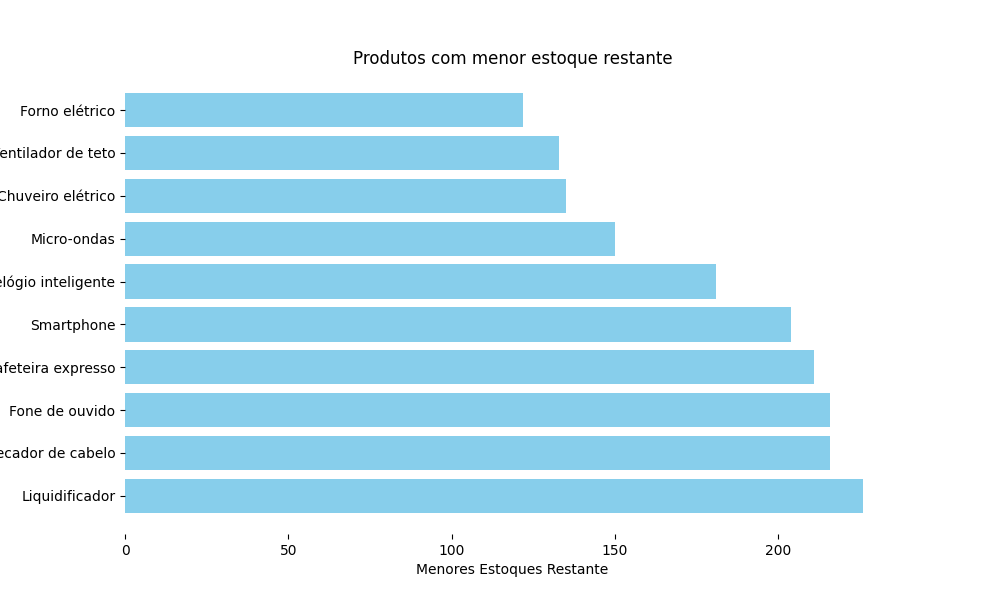

In [16]:
#Gerando gráfico de barras

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
plt.barh(df_menores_restantes['produto'], df_menores_restantes['estoque_restante'], color='skyblue')
plt.xlabel('Menores Estoques Restante')
plt.ylabel('Produto')
plt.title('Produtos com menor estoque restante')
plt.gca().invert_yaxis()
ax.set_frame_on(False)

%matplot plt